# Week 4 Assignment: The Good Casino
### Dynamic Casino Game — Random vs Martingale vs Kelly (Smart) Gambler

---

**Objective**: Simulate a dynamic casino environment where win probabilities change every round. Compare three betting strategies:
1. **Random Gambler** — bets a random % of bankroll, ignores the environment
2. **Martingale Gambler** — doubles bet after each loss for recovery
3. **Smart Gambler (Kelly Criterion)** — uses the Kelly formula to bet optimally based on the current edge

## Imports & Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print('Setup complete ')

Setup complete 


## Environment Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| p₀ | 0.50 | Base win probability (even odds) |
| αₜ | U(-0.05, +0.07) | Dynamic market edge each round |
| pₜ | p₀ + αₜ | Round win probability |
| b | 1:1 | Payout ratio |
| W₀ | $1,000 | Starting capital |
| T | 1,000 | Number of rounds |

In [12]:
# Environment parameters
P0 = 0.50           # Base win probability
ALPHA_MIN = -0.05   # Min dynamic edge
ALPHA_MAX = 0.07    # Max dynamic edge
PAYOUT = 1          # 1:1 payout
W0 = 1000           # Starting capital
T = 1000            # Rounds per simulation
N_PLAYERS = 100     # Number of players per strategy

print(f'Expected αₜ = {(ALPHA_MIN + ALPHA_MAX)/2:.4f}')
print(f'Expected pₜ = {P0 + (ALPHA_MIN + ALPHA_MAX)/2:.4f}')
print('Note: E[αₜ] = +0.01, so the environment has a SLIGHT positive edge on average!')

Expected αₜ = 0.0100
Expected pₜ = 0.5100
Note: E[αₜ] = +0.01, so the environment has a SLIGHT positive edge on average!


## Generate Shared Environment
All three players face the **exact same** sequence of edges (αₜ) and game outcomes each simulation.

In [13]:
def generate_environment(T):
    """
    Generate the shared environment for one simulation run.
    Returns:
        alphas: array of dynamic edges for each round
        p_wins: array of win probabilities for each round
        outcomes: array of True/False (win/loss) for each round
    """
    alphas = np.random.uniform(ALPHA_MIN, ALPHA_MAX, size=T)
    p_wins = P0 + alphas
    outcomes = np.random.random(T) < p_wins  # True = win
    return alphas, p_wins, outcomes

## Player 1: The Random Gambler
Ignores the environment entirely. Each round, picks a random integer percentage k ∈ [1, 10] and bets `floor(W × k/100)`.

In [14]:
def simulate_random_gambler(outcomes, T):
    """
    Random Gambler: bets a random 1-10% of current bankroll each round.
    Completely ignores the dynamic edge.
    """
    W = W0
    history = [W]

    for t in range(T):
        if W <= 0:
            history.extend([0] * (T - t))
            break

        k = np.random.randint(1, 11)  # k ∈ [1, 10]
        bet = int(W * k / 100)
        bet = max(1, min(bet, W))     # At least $1, at most all-in

        if outcomes[t]:  # Win
            W += bet
        else:            # Loss
            W -= bet

        history.append(W)

    return history

## Player 2: The Martingale Gambler
Ignores the environment. Focuses on loss recovery:
- Base bet = $10
- After win → reset to $10
- After loss → double the previous bet
- If bankroll < bet → go all-in

In [15]:
def simulate_martingale_gambler(outcomes, T):
    """
    Martingale Gambler: doubles bet after each loss.
    Ignores the dynamic edge. Pure loss-recovery strategy.
    """
    W = W0
    history = [W]
    bet = 10  # Base minimum bet

    for t in range(T):
        if W <= 0:
            history.extend([0] * (T - t))
            break

        # If bankroll < bet, go all-in
        actual_bet = min(bet, W)

        if outcomes[t]:  # Win
            W += actual_bet
            bet = 10     # Reset to base bet
        else:            # Loss
            W -= actual_bet
            bet = 2 * actual_bet  # Double the bet

        history.append(W)

    return history

## Player 3: The Smart Gambler (Kelly Criterion)
Observes the environment (αₜ) each round and computes the **Kelly fraction**:

$$f_t^* = \frac{b \cdot p_t - q_t}{b}$$

For b=1: $f_t^* = p_t - q_t = 2p_t - 1$

- If $f_t^* > 0$ (+EV): Bet $f_t^* \times W_t$
- If $f_t^* \leq 0$ (-EV): **Sit out** (bet $0)

In [16]:
def simulate_smart_gambler(outcomes, p_wins, T):
    """
    Smart Gambler: uses Kelly Criterion.
    Observes the dynamic edge and bets optimally.
    Sits out when the house has the edge (f* <= 0).
    """
    W = W0
    history = [W]

    for t in range(T):
        if W <= 0:
            history.extend([0] * (T - t))
            break

        pt = p_wins[t]
        qt = 1 - pt
        f_star = pt - qt  # Kelly fraction (simplified for b=1)

        if f_star > 0:  # +EV environment
            bet = f_star * W
            bet = min(bet, W)

            if outcomes[t]:  # Win
                W += bet
            else:            # Loss
                W -= bet
        # else: f_star <= 0, sit out (bet = 0)

        history.append(W)

    return history

## Run Full Simulation: 100 Players × 3 Strategies
All players share the **same** environment (same αₜ and game outcomes per run).

In [17]:
# Run 100 simulations for each player type
random_histories = []
martingale_histories = []
smart_histories = []

for i in range(N_PLAYERS):
    alphas, p_wins, outcomes = generate_environment(T)

    random_histories.append(simulate_random_gambler(outcomes, T))
    martingale_histories.append(simulate_martingale_gambler(outcomes, T))
    smart_histories.append(simulate_smart_gambler(outcomes, p_wins, T))

print(f'Simulated {N_PLAYERS} players for each of 3 strategies over {T} rounds ')

Simulated 100 players for each of 3 strategies over 1000 rounds 


## Results: Bankroll Timelines (Log Scale)
Plotting all 100 player trajectories for each strategy on a **log scale** as required.

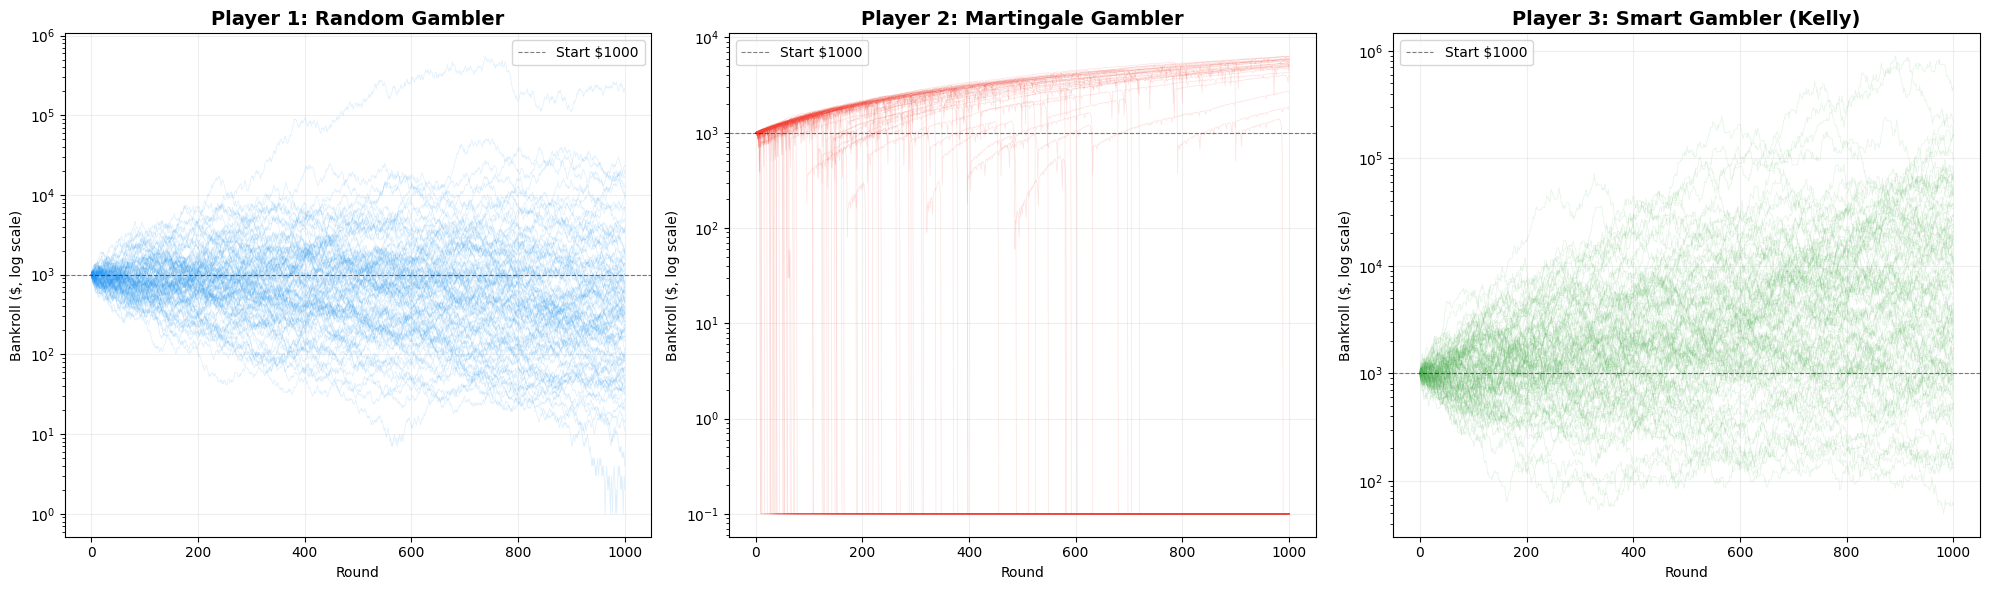

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Random Gambler ---
for h in random_histories:
    # Replace zeros with a small number for log scale
    h_plot = [max(v, 0.1) for v in h]
    axes[0].plot(h_plot, alpha=0.15, color='#2196F3', linewidth=0.5)
axes[0].set_yscale('log')
axes[0].set_title('Player 1: Random Gambler', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Bankroll ($, log scale)')
axes[0].axhline(y=W0, color='black', ls='--', lw=0.8, alpha=0.5, label=f'Start ${W0}')
axes[0].legend(); axes[0].grid(True, alpha=0.2)

# --- Martingale Gambler ---
for h in martingale_histories:
    h_plot = [max(v, 0.1) for v in h]
    axes[1].plot(h_plot, alpha=0.15, color='#F44336', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_title('Player 2: Martingale Gambler', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Bankroll ($, log scale)')
axes[1].axhline(y=W0, color='black', ls='--', lw=0.8, alpha=0.5, label=f'Start ${W0}')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

# --- Smart Gambler ---
for h in smart_histories:
    h_plot = [max(v, 0.1) for v in h]
    axes[2].plot(h_plot, alpha=0.15, color='#4CAF50', linewidth=0.5)
axes[2].set_yscale('log')
axes[2].set_title('Player 3: Smart Gambler (Kelly)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Round'); axes[2].set_ylabel('Bankroll ($, log scale)')
axes[2].axhline(y=W0, color='black', ls='--', lw=0.8, alpha=0.5, label=f'Start ${W0}')
axes[2].legend(); axes[2].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()

## Summary Statistics

In [19]:
def final_stats(histories, name):
    finals = [h[-1] for h in histories]
    busted = sum(1 for f in finals if f <= 0)
    alive = [f for f in finals if f > 0]

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Players busted     : {busted}/{len(finals)}')
    print(f'  Survival rate      : {(len(finals)-busted)/len(finals):.0%}')
    if alive:
        print(f'  Mean final bankroll: ${np.mean(alive):.2f}')
        print(f'  Median final       : ${np.median(alive):.2f}')
        print(f'  Max final          : ${np.max(alive):.2f}')
        print(f'  Min final (alive)  : ${np.min(alive):.2f}')
    print(f'{"="*50}')

final_stats(random_histories, 'Player 1: Random Gambler')
final_stats(martingale_histories, 'Player 2: Martingale Gambler')
final_stats(smart_histories, 'Player 3: Smart Gambler (Kelly)')


  Player 1: Random Gambler
  Players busted     : 0/100
  Survival rate      : 100%
  Mean final bankroll: $3948.83
  Median final       : $378.00
  Max final          : $219017.00
  Min final (alive)  : $2.00

  Player 2: Martingale Gambler
  Players busted     : 75/100
  Survival rate      : 25%
  Mean final bankroll: $5180.80
  Median final       : $5410.00
  Max final          : $6330.00
  Min final (alive)  : $1860.00

  Player 3: Smart Gambler (Kelly)
  Players busted     : 0/100
  Survival rate      : 100%
  Mean final bankroll: $25927.54
  Median final       : $5193.34
  Max final          : $464125.95
  Min final (alive)  : $59.96


## Combined Comparison Plot

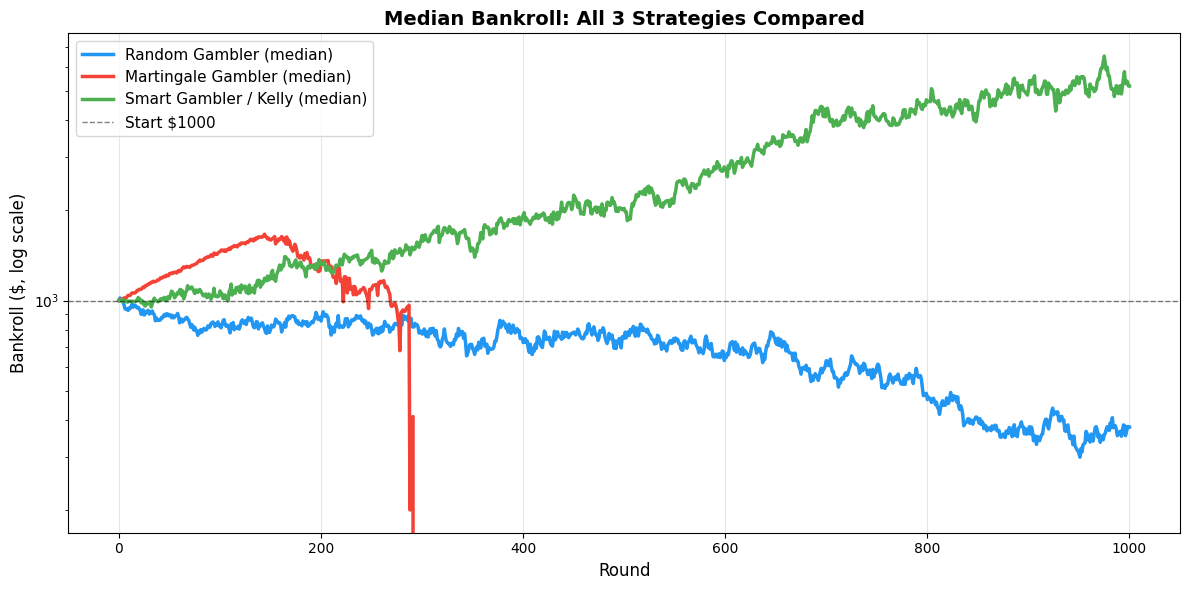

In [20]:
# Plot median trajectory for each strategy
def median_trajectory(histories):
    max_len = max(len(h) for h in histories)
    padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
    return np.median(padded, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
rounds = np.arange(T + 1)

ax.plot(rounds, median_trajectory(random_histories), color='#2196F3', lw=2.5, label='Random Gambler (median)')
ax.plot(rounds, median_trajectory(martingale_histories), color='#F44336', lw=2.5, label='Martingale Gambler (median)')
ax.plot(rounds, median_trajectory(smart_histories), color='#4CAF50', lw=2.5, label='Smart Gambler / Kelly (median)')

ax.set_yscale('log')
ax.axhline(y=W0, color='black', ls='--', lw=1, alpha=0.5, label=f'Start ${W0}')
ax.set_xlabel('Round', fontsize=12); ax.set_ylabel('Bankroll ($, log scale)', fontsize=12)
ax.set_title('Median Bankroll: All 3 Strategies Compared', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Research: Card Counting in Blackjack

### Why Card Counting Beats Basic Strategy

**Basic strategy** in Blackjack is a fixed set of rules (hit, stand, double, split) based purely on the player's hand and the dealer's upcard. It minimizes the house edge to about **0.5%** but cannot eliminate it  the player still loses in the long run because basic strategy assumes each hand is independent and has no memory of past cards.

**Card counting** (e.g., Hi-Lo system) exploits the fact that Blackjack is dealt from a finite shoe without replacement. By tracking the ratio of high cards (10s, Aces) to low cards remaining, a counter knows when the deck is "rich" in high cards  a state that favors the player (more Blackjacks at 3:2 payout, dealer busts more with stiff hands). When the "true count" is high, the counter increases their bet size (positive Kelly fraction); when the count is negative, they bet the minimum or sit out. This is **exactly the Smart Gambler / Kelly Criterion approach** from our simulation dynamically adjusting bet size based on a shifting edge (αₜ). The counter transforms Blackjack from a negative-EV game into a conditionally positive-EV game, gaining a **1–2% long-run edge**.

### Why Blackjack is the Only Beatable Casino Game

Most casino games (roulette, slots, craps) have **independent** trials  each spin or roll has the same fixed probability regardless of history. There's no information to exploit. Blackjack is unique because cards are dealt **without replacement** from a shoe, making successive hands **statistically dependent**. This memory in the deck creates exploitable information that a skilled player can use to shift the edge in their favor. No other standard casino game has this property  which is why casinos use multiple decks, shuffle frequently, and ban counters.